# Full Hand-Sequence Gesture Classification (LSTM)

This notebook trains a gesture classifier using **full-hand landmark sequences** (21 keypoints × 2D per frame),
with **TIME_STEPS = 16** frames and **NUM_CLASSES = 5**.

## Expected dataset
- CSV file: `model/full_sequence_classifier/full_sequence.csv`
- Row format: `[class_id, frame1(42 vals), frame2(42 vals), ..., frame16(42 vals)]` => total 1 + 16×42 columns.
- Labels: `model/full_sequence_classifier/full_sequence_classifier_label.csv` (one label per line, row index = class id).

> Make sure your data were collected with the same preprocessing as runtime (relative to wrist + normalization).


In [109]:
import os, time, csv
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# Paths and hyperparams
DATASET = 'model/full_sequence_classifier/full_sequence.csv'
LABELS_PATH = 'model/full_sequence_classifier/full_sequence_classifier_label.csv'
MODEL_DIR = 'model/full_sequence_classifier'
MODEL_SAVE_PATH = os.path.join(MODEL_DIR, 'full_sequence_classifier.hdf5')
TFLITE_PATH = os.path.join(MODEL_DIR, 'full_sequence_classifier.tflite')

# --------------------
# 超参
# --------------------
NUM_CLASSES   = 5
TIME_STEPS    = 16
KP_NUM        = 21
DIM_PER_FRAME = 42   # 21 * (x,y)
INPUT_LEN     = TIME_STEPS * DIM_PER_FRAME
RANDOM_SEED   = 42
BATCH_SIZE    = 128
EPOCHS        = 200
WRIST_IDX     = 0    # MediaPipe 手腕通常是 0 号关键点（如不同请据实际调整）
# 两点定义掌宽：例：0-9（腕-中指MCP）或 5-17（食指MCP-无名指MCP）
PALM_A, PALM_B = 5, 17

tf.keras.utils.set_random_seed(RANDOM_SEED)

os.makedirs(MODEL_DIR, exist_ok=True)
print(tf.__version__)


2.15.1


In [110]:

# --------------------
# 读取数据
# --------------------
usecols = list(range(1, INPUT_LEN + 1))
X = np.loadtxt(DATASET, delimiter=',', dtype='float32', usecols=usecols)
y = np.loadtxt(DATASET, delimiter=',', dtype='int32', usecols=(0,))
assert X.shape[1] == INPUT_LEN
assert y.ndim == 1
assert np.all(np.logical_and(y >= 0, y < NUM_CLASSES)), "检查标签范围是否与 NUM_CLASSES 一致"


    Input  (batch, T=16, F=126)
      │
      ├─ Dropout(p=0.2)                         → (batch, 16, 126)
      │
      ├─ BiLSTM#1: LSTM(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1)
      │       ├─ Forward LSTM(128)
      │       └─ Backward LSTM(128)
      │      [concat forward/backward]         → (batch, 16, 256)
      │
      ├─ BiLSTM#2: LSTM(128, return_sequences=False, dropout=0.1, recurrent_dropout=0.1)
      │       ├─ Forward LSTM(128) last step
      │       └─ Backward LSTM(128) last step
      │      [concat last steps]               → (batch, 256)
      │
      ├─ BatchNormalization                    → (batch, 256)
      │
      ├─ Dense(128) + ReLU                     → (batch, 128)
      │
      ├─ Dropout(p=0.3)                        → (batch, 128)
      │
      └─ Dense(C) (no activation, logits)      → (batch, C=5)

In [116]:
# --------------------
# 预处理函数
# 1) reshape: (N, T, 21, 2)
# 2) 相对坐标：减去手腕
# 3) 尺度归一化：除以掌宽（防止尺度差异）
# 4) 速度/加速度特征：Δ 和 Δ²
# 5) 标准化：对 (位置+速度+加速度) 在训练集统计量做标准化
# --------------------
def preprocess_add_feats(X_flat):
    N = X_flat.shape[0]
    X_seq = X_flat.reshape(N, TIME_STEPS, KP_NUM, 2)  # (N, T, 21, 2)

    # 平移到以手腕为原点
    wrist = X_seq[:, :, WRIST_IDX:WRIST_IDX+1, :]           # (N, T, 1, 2)
    X_rel = X_seq - wrist                                    # 相对坐标

    # 掌宽做尺度：避免除0，添加极小值
    p_a = X_seq[:, :, PALM_A, :]    # (N, T, 2)
    p_b = X_seq[:, :, PALM_B, :]    # (N, T, 2)
    palm_len = np.linalg.norm(p_a - p_b, axis=-1, keepdims=True)  # (N, T, 1)
    palm_len = np.maximum(palm_len, 1e-6)
    X_norm = X_rel / palm_len[:, :, None, :]                  # 位置归一化 (N, T, 21, 2)

    # 展平到 (N, T, 42)
    pos = X_norm.reshape(N, TIME_STEPS, KP_NUM*2)

    # 速度与加速度 (前向差分；首帧补 0)
    vel = np.zeros_like(pos)
    vel[:, 1:, :] = pos[:, 1:, :] - pos[:, :-1, :]

    acc = np.zeros_like(pos)
    acc[:, 2:, :] = vel[:, 2:, :] - vel[:, 1:-1, :]

    # 拼接特征：位置 + 速度 + 加速度 => (N, T, 42*3)
    X_full = np.concatenate([pos, vel, acc], axis=-1)
    return X_full.astype('float32')

# Focal loss for multi classes
def sparse_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.nn.softmax(y_pred)
        y_true = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)  # 去掉多余维度
        y_true = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        probs = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal = alpha * tf.pow(1. - probs, gamma) * cross_entropy
        return focal
    return loss

# 先划分再用训练集统计量做标准化，避免数据泄漏
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=RANDOM_SEED, stratify=y
)

X_train_f = preprocess_add_feats(X_train)  # (N, T, 126)
X_test_f  = preprocess_add_feats(X_test)

# 标准化（train 的均值方差）
mean = X_train_f.mean(axis=(0,1), keepdims=True)
std  = X_train_f.std(axis=(0,1), keepdims=True) + 1e-6
X_train_f = (X_train_f - mean) / std
X_test_f  = (X_test_f  - mean) / std
# 保存 mean 和 std 到文件
np.save('model/full_sequence_classifier/mean.npy', mean)
np.save('model/full_sequence_classifier/std.npy', std)

# --------------------
# 模型：BiLSTM + logits 头
# --------------------
inputs = tf.keras.Input(shape=(TIME_STEPS, X_train_f.shape[-1]))  # (T, 126)
x = tf.keras.layers.Dropout(0.2)(inputs)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
    128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
    128, return_sequences=False, dropout=0.1, recurrent_dropout=0.1))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.35)(x)

logits = tf.keras.layers.Dense(NUM_CLASSES)(x)  # 无激活 => logits
model = tf.keras.Model(inputs, logits)
model.summary()

# 优化器 + 调度 + 梯度裁剪（更稳）
base_lr   = 3e-4
# optimizer = tf.keras.optimizers.Adam(learning_rate=base_lr, clipnorm=1.0)
schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=base_lr, first_decay_steps=1500, t_mul=2.0, m_mul=0.8, alpha=1e-2
)

try:
    optimizer = tf.keras.optimizers.AdamW(learning_rate=schedule, weight_decay=1e-4, clipnorm=0.5)
except:
    # 没有 AdamW 就用 Adam + L2 正则化
    optimizer = tf.keras.optimizers.Adam(learning_rate=schedule)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    # loss=sparse_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# 类别权重（如不均衡则启用）
classes = np.unique(y_train)
class_weight = None
if len(classes) == NUM_CLASSES:
    counts = np.bincount(y_train, minlength=NUM_CLASSES)
    if counts.max() / counts.min() >= 1.5:  # 简单阈值判断是否不均衡
        cw = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weight = {int(c): float(w) for c, w in zip(classes, cw)}

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                         min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
]

hist = model.fit(
    X_train_f, y_train,
    validation_data=(X_test_f, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    class_weight=class_weight
)


Model: "model_21"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_27 (InputLayer)       [(None, 16, 126)]         0         
                                                                 
 dropout_52 (Dropout)        (None, 16, 126)           0         
                                                                 
 bidirectional_42 (Bidirect  (None, 16, 256)           261120    
 ional)                                                          
                                                                 
 bidirectional_43 (Bidirect  (None, 256)               394240    
 ional)                                                          
                                                                 
 batch_normalization_21 (Ba  (None, 256)               1024      
 tchNormalization)                                               
                                                          

c:\workspace\dynamic-hand-gesture-recognition-mediapipe\venv-mp311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3/3 [==============================] - 4s 1s/step - loss: 0.8773 - accuracy: 0.5785 - val_loss: 1.3638 - val_accuracy: 0.5104 - lr: 2.9999e-04
Epoch 3/200
3/3 [==============================] - 6s 2s/step - loss: 0.6893 - accuracy: 0.6335 - val_loss: 1.3154 - val_accuracy: 0.5938 - lr: 2.9998e-04
Epoch 4/200
3/3 [==============================] - 5s 2s/step - loss: 0.6252 - accuracy: 0.6937 - val_loss: 1.2789 - val_accuracy: 0.6146 - lr: 2.9996e-04
Epoch 5/200
3/3 [==============================] - 6s 2s/step - loss: 0.5981 - accuracy: 0.6780 - val_loss: 1.2477 - val_accuracy: 0.6354 - lr: 2.9994e-04
Epoch 6/200
3/3 [==============================] - 6s 2s/step - loss: 0.5067 - accuracy: 0.7277 - val_loss: 1.2204 - val_accuracy: 0.6875 - lr: 2.9991e-04
Epoch 7/200
3/3 [==============================] - 9s 3s/step - loss: 0.4676 - accuracy: 0.7565 - val_loss: 1.1971 - val_accuracy: 0.6979 - lr: 2.9987e-04
Epoch 8/200
3/3 [==============================] - 5s 2s/step - loss: 0.4688 - acc

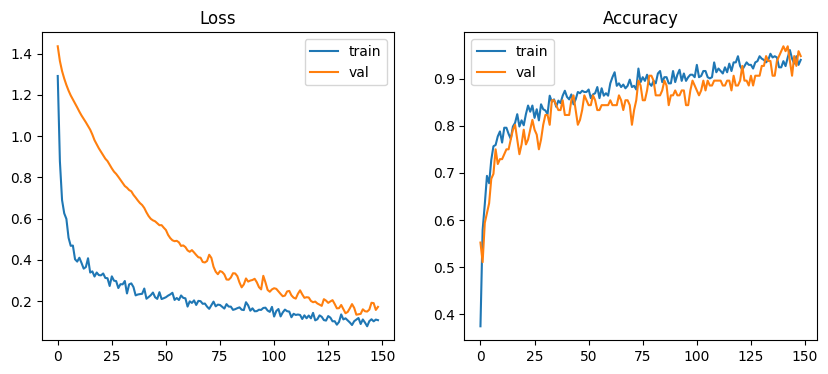

Test acc: 0.9479166865348816


In [117]:
# Plot curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(hist.history['loss'], label='train'); plt.plot(hist.history['val_loss'], label='val'); plt.title('Loss'); plt.legend();
plt.subplot(1,2,2); plt.plot(hist.history['accuracy'], label='train'); plt.plot(hist.history['val_accuracy'], label='val'); plt.title('Accuracy'); plt.legend();
plt.show()

test_loss, test_acc = model.evaluate(X_test_f, y_test, verbose=0)
print('Test acc:', test_acc)


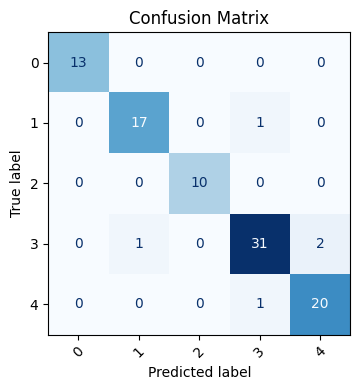

In [118]:
# (Optional) Confusion matrix
try:
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    # 1) 用与训练一致的预处理数据
    X_eval = X_test_f  # ✅ 不要用 X_test

    # 2) 预测（模型若输出 logits，直接 argmax 也可以）
    y_logits = model.predict(X_eval, batch_size=256, verbose=0)
    # 如果你想用概率：
    # y_prob = tf.nn.softmax(y_logits, axis=1).numpy()
    # y_pred = y_prob.argmax(axis=1)
    y_pred = y_logits.argmax(axis=1)

    # 3) 混淆矩阵
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(NUM_CLASSES))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('Confusion matrix skipped:', e)


In [119]:
# Export TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# 允许同时使用 TFLite 内置算子 + 一小部分 TensorFlow 原生算子（Select TF Ops）
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print('Saved TFLite to', TFLITE_PATH)


INFO:tensorflow:Assets written to: C:\Users\qichsun\AppData\Local\Temp\tmpypw4dy5w\assets


INFO:tensorflow:Assets written to: C:\Users\qichsun\AppData\Local\Temp\tmpypw4dy5w\assets


Saved TFLite to model/full_sequence_classifier\full_sequence_classifier.tflite


In [120]:
import numpy as np
import tensorflow as tf

# === 1) 建立/分配解释器 ===
try:
    from tensorflow.lite.python.interpreter import Interpreter
except Exception:
    import tflite_runtime.interpreter as tflite
    Interpreter = tflite.Interpreter

interpreter = Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

in_details  = interpreter.get_input_details()[0]
out_details = interpreter.get_output_details()[0]

in_idx  = in_details['index']
out_idx = out_details['index']

print("TFLite input spec:",
      "shape=", in_details['shape'],
      "dtype=", in_details['dtype'],
      "quant=", in_details.get('quantization', None))
print("TFLite output spec:",
      "shape=", out_details['shape'],
      "dtype=", out_details['dtype'],
      "quant=", out_details.get('quantization', None))

# === 2) 准备一条测试样本 ===
# 关键点：不要用 X_test（展平 672），而是用训练时同一套预处理后的 X_test_f
# 并确保形状是 (1, 16, 126)
x0 = X_test_f[:1].astype('float32')           # 形状应为 (1, TIME_STEPS=16, 126)

# 如果你的 TFLite 模型输入是动态尺寸/不同 batch，必要时 resize 到 (1,16,126)
need_resize = False
expected_shape = tuple(in_details['shape'])
if expected_shape[0] == -1 or expected_shape[1:] != x0.shape[1:]:
    need_resize = True

if need_resize:
    # 注意：某些 TFLite 构建允许动态 batch/seq；resize 后要重新 allocate_tensors
    interpreter.resize_tensor_input(in_idx, x0.shape)
    interpreter.allocate_tensors()
    in_details  = interpreter.get_input_details()[0]
    out_details = interpreter.get_output_details()[0]
    in_idx  = in_details['index']
    out_idx = out_details['index']
    print("Resized input to:", in_details['shape'])

# === 3) 若是量化模型，做量化/反量化处理 ===
# 输入量化参数
in_scale, in_zero = (0.0, 0)
if 'quantization' in in_details and in_details['quantization'] is not None:
    in_scale, in_zero = in_details['quantization']

x_feed = x0
if in_details['dtype'] == np.uint8:
    # 浮点 -> 量化： x_q = x_f / scale + zero_point
    x_feed = np.clip(np.round(x0 / in_scale + in_zero), 0, 255).astype(np.uint8)
elif in_details['dtype'] == np.int8:
    # 浮点 -> 对称量化（通常 zero_point 约为 0）
    x_feed = np.clip(np.round(x0 / in_scale + in_zero), -128, 127).astype(np.int8)
# 如果是 float32，就直接用 x0

# === 4) 推理 ===
interpreter.set_tensor(in_idx, x_feed)
interpreter.invoke()
y0 = interpreter.get_tensor(out_idx)[0]  # 取 batch=0 的输出

# === 5) 如果输出是量化的，先反量化；若是 logits，可再 softmax ===
out_scale, out_zero = (0.0, 0)
if 'quantization' in out_details and out_details['quantization'] is not None:
    out_scale, out_zero = out_details['quantization']

if out_details['dtype'] in (np.uint8, np.int8):
    y0 = (y0.astype('float32') - out_zero) * out_scale  # 反量化到浮点

# Keras 端是 logits 输出（Dense(NUM_CLASSES) 无激活，loss from_logits=True）
# 因此这里对 y0 做 softmax 更直观；如果在 TFLite 端已经 fused softmax，可以跳过。
y0_prob = tf.nn.softmax(y0, axis=-1).numpy()
pred = int(np.argmax(y0_prob))

print('TFLite output (prob):', np.round(y0_prob, 4), 'argmax=', pred)


TFLite input spec: shape= [  1  16 126] dtype= <class 'numpy.float32'> quant= (0.0, 0)
TFLite output spec: shape= [1 5] dtype= <class 'numpy.float32'> quant= (0.0, 0)
TFLite output (prob): [4.000e-04 4.000e-04 1.000e-04 3.000e-04 9.988e-01] argmax= 4
